# Прогнозирование потребления электроэнергии по погодным данным — Финляндия (2015–2020)

**Автор:** Алишер Рысбек

---

Финляндия — холодная энергосистема с зимним пиком нагрузки и широко распространённым
электрическим отоплением. Когда температура падает, национальное потребление
электроэнергии резко растёт. Этот ноутбук измеряет силу такой зависимости и строит
модель, предсказывающую почасовое потребление **только по погодным и календарным
признакам**.

Датасет **собирается самостоятельно из двух первичных источников**, а не загружается
готовым файлом:

1. **Потребление электроэнергии** — почасовая измеренная нагрузка Финляндии,
   публикуемая финским системным оператором через платформу прозрачности ENTSO-E
   и распространяемая проектом Open Power System Data (OPSD).
2. **Погода** — почасовой реанализ ERA5 по трём финским городам, полученный через
   Open-Meteo Historical Weather API (бесплатно, без API-ключа, лицензия CC BY 4.0).

**Почему Финляндия?** Проект мотивирован Казахстаном — страной с такой же зимней
пиковой нагрузкой, но без открытых почасовых данных о потреблении. Финляндия —
ближайший аналог, для которого реальные данные системного оператора доступны.
Подробнее см. раздел «Заключение».

---

### Структура ноутбука

| Раздел | Этап проекта |
|---|---|
| 1 | Выбор набора данных |
| 2 | Введение и цели |
| 3 | Сбор данных |
| 4 | Описание данных |
| 5 | Исследовательские вопросы |
| 6 | Подготовка и очистка данных |
| 7 | Анализ и визуализация данных |
| 8 | Модели машинного обучения |
| 9 | Заключение, ограничения, дальнейшая работа |

## 0. Подготовка окружения

Установите недостающие пакеты и импортируйте всё, что используется в ноутбуке.
Библиотека `holidays` нужна для отметки государственных праздников Финляндии —
они заметно влияют на потребление.

In [4]:
# Выполните один раз, если пакеты ещё не установлены:
# !pip install pandas numpy scikit-learn matplotlib seaborn requests holidays

import warnings
from pathlib import Path

import holidays
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

warnings.filterwarnings("ignore")

# Единое оформление для всех графиков ноутбука.
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

# Папки для кэша исходных данных и экспорта графиков.
DATA_DIR = Path("data")
IMG_DIR = Path("images")
DATA_DIR.mkdir(exist_ok=True)
IMG_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
print("Окружение готово.")

Окружение готово.


## 1. Выбор набора данных

**Требование:** выбрать набор данных достаточного размера и сложности для
полноценного анализа и обосновать выбор.

Здесь объединяются два набора данных.

**Потребление — Open Power System Data, `time_series_60min_singleindex.csv`**

OPSD переопубликовывает почасовые ряды нагрузки, ветровой и солнечной генерации по
странам Европы, получая их от национальных системных операторов через платформу
прозрачности ENTSO-E. Финский столбец нагрузки — это измеренное национальное
потребление в МВт. Полный набор доступен с 2015 года; обновление OPSD прекратилось
в 2020 году, поэтому рабочее окно — примерно **с 2015-01-01 по 2020-09-30**, около
**50 000 почасовых наблюдений**.

**Погода — Open-Meteo Historical Weather API (реанализ ERA5)**

ERA5 — реанализ европейской программы Copernicus. Он объединяет наблюдения
метеостанций, самолётов, буёв, радаров и спутников с численной моделью погоды и
даёт *пространственно полный* ряд: без пропусков и с покрытием точек, рядом с
которыми нет метеостанций. Это тот же класс погодных входных данных, на которых
строятся профили спроса и генерации в энергосистемных моделях вроде PyPSA.


## 2. Введение и цели

Электроэнергию нельзя запасать в промышленных масштабах, поэтому предложение должно
совпадать со спросом каждый час каждого дня. Системному оператору необходимо знать,
сколько электроэнергии будет потреблено, ещё до того, как она будет потреблена.
В холодной стране главный драйвер этого спроса — погода: при электрическом отоплении
падение температуры почти напрямую превращается в дополнительную нагрузку на сеть.

**Цели работы:**

1. Измерить, насколько сильно погода определяет потребление электроэнергии в
   Финляндии, и выявить, какая погодная переменная важнее всего.
2. Описать суточную, недельную и сезонную форму потребления.
3. Построить и оценить модель, предсказывающую почасовое потребление только по
   погодным и календарным признакам — без авторегрессии, без знания вчерашнего
   потребления.
4. Честно оценить, где такая модель ошибается и почему.

**Практическая значимость.** Прогноз спроса определяет, сколько генерирующей
мощности нужно запланировать и сколько резерва держать. Там, где этот резерв
угольный, качество прогноза имеет прямую эмиссионную цену. Ограничение особенно
жёсткое в системах с зимним пиком: максимальный спрос совпадает с условиями, в
которых отказ наименее переносим.

## 3. Сбор данных

### 3.1 Потребление электроэнергии

Файл OPSD большой (около 100 МБ, несколько сотен столбцов по ~37 странам). Сначала
читаем только заголовок, затем запрашиваем лишь нужные столбцы — это удерживает
потребление памяти на минимуме.

> **Если ссылка ниже возвращает ошибку 404:** OPSD публикует версионированные
> релизы. Откройте <https://data.open-power-system-data.org/time_series/>,
> скопируйте актуальную ссылку на `time_series_60min_singleindex.csv` и обновите
> переменную `OPSD_URL`.

In [5]:
COUNTRY = "FI"  # замените на "EE" или "PL", чтобы прогнать тот же пайплайн по другой стране

OPSD_URL = (
    "https://data.open-power-system-data.org/time_series/2020-10-06/"
    "time_series_60min_singleindex.csv"
)
opsd_cache = DATA_DIR / "opsd_load_raw.csv"

if opsd_cache.exists():
    # Используем кэш, чтобы ноутбук можно было перезапускать офлайн.
    load_raw = pd.read_csv(opsd_cache, parse_dates=["utc_timestamp"])
    print(f"Загружено из кэша: {load_raw.shape}")
else:
    # Шаг 1: читаем только заголовок, чтобы узнать доступные имена столбцов.
    header = pd.read_csv(OPSD_URL, nrows=0)
    country_cols = [c for c in header.columns if c.startswith(f"{COUNTRY}_")]
    print(f"Доступные столбцы для страны {COUNTRY}:")
    for c in country_cols:
        print("   ", c)

Доступные столбцы для страны FI:
    FI_load_actual_entsoe_transparency
    FI_load_forecast_entsoe_transparency
    FI_wind_onshore_generation_actual


Обычно для каждой страны существует два столбца нагрузки: один из платформы
прозрачности ENTSO-E, другой из ENTSO-E Power Statistics. Они собираются по разным
методикам и не совпадают. Мы используем ряд **платформы прозрачности** и явно
фиксируем этот выбор — необъяснённое переключение между источниками одна из самых
частых и легко устранимых причин путаницы.

In [6]:
LOAD_COL = f"{COUNTRY}_load_actual_entsoe_transparency"

if not opsd_cache.exists():
    # Шаг 2: скачиваем только метку времени и нужный столбец нагрузки.
    load_raw = pd.read_csv(
        OPSD_URL,
        usecols=["utc_timestamp", LOAD_COL],
        parse_dates=["utc_timestamp"],
    )
    load_raw.to_csv(opsd_cache, index=False)  # кэшируем для офлайн-перезапусков
    print(f"Скачано и закэшировано: {load_raw.shape}")

load_raw = load_raw.rename(columns={LOAD_COL: "load_mw"})
load_raw = load_raw.dropna(subset=["load_mw"]).reset_index(drop=True)

print(f"\nСтрок: {len(load_raw):,}")
print(f"Период: {load_raw['utc_timestamp'].min()} — {load_raw['utc_timestamp'].max()}")
load_raw.head()

Скачано и закэшировано: (50401, 2)

Строк: 50,388
Период: 2015-01-01 01:00:00+00:00 — 2020-09-30 22:00:00+00:00


,utc_timestamp,load_mw
0,2015-01-01 01:00:00+00:00,8735.4
1,2015-01-01 02:00:00+00:00,8626.4
2,2015-01-01 03:00:00+00:00,8674.1
3,2015-01-01 04:00:00+00:00,8845.3
4,2015-01-01 05:00:00+00:00,8877.0


### 3.2 Погодные данные

Одна метеостанция не может представлять отопительную нагрузку целой страны. Берём
три города, охватывающих Финляндию с юга на север, и сводим их в **национальную
температуру, взвешенную по численности населения**. Это стандартная практика в
прогнозировании нагрузки: спрос следует за людьми, а не за географией.

Архивный эндпоинт Open-Meteo не требует API-ключа. Один запрос возвращает полный
многолетний почасовой ряд для одной точки.

**Метки времени запрашиваются в UTC, чтобы совпадать с данными OPSD.** Ошибка здесь
сдвигает суточную кривую нагрузки на несколько часов и незаметно обесценивает все
последующие результаты.

In [7]:
# Веса — приблизительные доли трёх агломераций; используются для взвешивания
# вклада каждого города в национальный погодный ряд.
CITIES = {
    "helsinki": {"lat": 60.17, "lon": 24.94, "weight": 0.60},
    "tampere":  {"lat": 61.50, "lon": 23.79, "weight": 0.25},
    "oulu":     {"lat": 65.01, "lon": 25.47, "weight": 0.15},
}

START_DATE = "2015-01-01"
END_DATE = "2020-09-30"

WEATHER_VARS = [
    "temperature_2m",
    "relative_humidity_2m",
    "wind_speed_10m",
    "cloud_cover",
]


def fetch_weather(lat, lon, start, end, variables):
    """Загружает почасовой реанализ ERA5 для одной точки через Open-Meteo.

    Возвращает DataFrame с индексом по меткам времени UTC. API-ключ не нужен:
    архивный эндпоинт бесплатен для некоммерческого использования (CC BY 4.0).
    """
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start,
        "end_date": end,
        "hourly": ",".join(variables),
        "timezone": "UTC",  # должно совпадать с метками времени OPSD
    }
    response = requests.get(url, params=params, timeout=90)
    response.raise_for_status()
    hourly = response.json()["hourly"]

    df = pd.DataFrame(hourly)
    df["utc_timestamp"] = pd.to_datetime(df.pop("time"), utc=True)
    return df.set_index("utc_timestamp")

In [8]:
weather_cache = DATA_DIR / "weather_raw.csv"

if weather_cache.exists():
    weather_wide = pd.read_csv(weather_cache, parse_dates=["utc_timestamp"])
    weather_wide["utc_timestamp"] = pd.to_datetime(
        weather_wide["utc_timestamp"], utc=True
    )
    weather_wide = weather_wide.set_index("utc_timestamp")
    print(f"Погода загружена из кэша: {weather_wide.shape}")
else:
    frames = []
    for city, info in CITIES.items():
        print(f"Загружаем {city}...")
        city_df = fetch_weather(
            info["lat"], info["lon"], START_DATE, END_DATE, WEATHER_VARS
        )
        city_df.columns = [f"{col}_{city}" for col in city_df.columns]
        frames.append(city_df)

    weather_wide = pd.concat(frames, axis=1)
    weather_wide.to_csv(weather_cache)
    print(f"Загружено и закэшировано: {weather_wide.shape}")

weather_wide.head()

Загружаем helsinki...
Загружаем tampere...
Загружаем oulu...
Загружено и закэшировано: (50400, 12)


,temperature_2m_helsinki,relative_humidity_2m_helsinki,wind_speed_10m_helsinki,cloud_cover_helsinki,temperature_2m_tampere,relative_humidity_2m_tampere,wind_speed_10m_tampere,cloud_cover_tampere,temperature_2m_oulu,relative_humidity_2m_oulu,wind_speed_10m_oulu,cloud_cover_oulu
utc_timestamp,,,,,,,,,,,,
2015-01-01 00:00:00+00:00,2.3,93,15.0,93,0.7,96,14.6,93,1.4,93,13.8,100
2015-01-01 01:00:00+00:00,2.2,93,14.5,54,0.7,96,14.4,88,1.4,93,14.7,100
2015-01-01 02:00:00+00:00,2.0,93,13.3,69,0.7,96,13.7,98,1.4,93,14.8,100
2015-01-01 03:00:00+00:00,1.7,94,13.8,53,0.7,96,13.4,96,1.5,92,14.7,99
2015-01-01 04:00:00+00:00,1.5,94,14.9,60,0.6,96,13.5,100,1.7,92,15.5,27


In [9]:
# Сводим три города в единые национальные ряды, взвешенные по населению.
weather = pd.DataFrame(index=weather_wide.index)

for var in WEATHER_VARS:
    weighted = sum(
        weather_wide[f"{var}_{city}"] * info["weight"]
        for city, info in CITIES.items()
    )
    weather[var] = weighted

weather = weather.rename(
    columns={
        "temperature_2m": "temperature",
        "relative_humidity_2m": "humidity",
        "wind_speed_10m": "wind_speed",
        "cloud_cover": "cloud_cover",
    }
)

print(f"Национальный погодный ряд: {weather.shape}")
weather.describe().round(2)

Национальный погодный ряд: (50400, 4)


,temperature,humidity,wind_speed,cloud_cover
count,50400.00,50400.00,50400.00,50400.00
mean,6.26,80.49,14.24,69.34
std,8.42,13.79,5.89,31.84
min,-23.58,29.95,1.49,0.00
25%,0.17,72.60,9.75,44.55
50%,5.23,84.10,13.44,82.65
75%,13.45,91.35,17.90,97.95
max,28.88,100.00,40.33,100.00


## 4. Описание данных

**Требование:** описать размер, столбцы, типы данных, а также задокументировать
пропущенные значения и обсудить их влияние на анализ.

In [10]:
# Приводим оба источника к единому почасовому индексу UTC и объединяем.
load = load_raw.copy()
load["utc_timestamp"] = pd.to_datetime(load["utc_timestamp"], utc=True)
load = load.set_index("utc_timestamp")

df = load.join(weather, how="inner")

print(f"Объединённый датасет: {df.shape[0]:,} строк x {df.shape[1]} столбцов")
print(f"Период: {df.index.min()} — {df.index.max()}")
print()
df.info()

Объединённый датасет: 50,388 строк x 5 столбцов
Период: 2015-01-01 01:00:00+00:00 — 2020-09-30 22:00:00+00:00

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 50388 entries, 2015-01-01 01:00:00+00:00 to 2020-09-30 22:00:00+00:00
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   load_mw      50388 non-null  float64
 1   temperature  50388 non-null  float64
 2   humidity     50388 non-null  float64
 3   wind_speed   50388 non-null  float64
 4   cloud_cover  50388 non-null  float64
dtypes: float64(5)
memory usage: 2.3 MB


In [ ]:
# Описательные статистики: среднее, стандартное отклонение, квартили, экстремумы.
df.describe().round(2)

In [11]:
# Аудит пропущенных значений.
missing = pd.DataFrame({
    "пропусков": df.isna().sum(),
    "доля_%": (df.isna().sum() / len(df) * 100).round(3),
})
print(missing)

# Пропущенные *метки времени* — отдельная проблема от пропущенных *значений*:
# разрыв в индексе метод isna() не видит.
expected = pd.date_range(df.index.min(), df.index.max(), freq="h", tz="UTC")
gaps = expected.difference(df.index)
print(f"\nОжидаемое число почасовых меток: {len(expected):,}")
print(f"Фактически присутствует:          {len(df):,}")
print(f"Пропущено меток времени:          {len(gaps):,}")

if len(gaps) > 0:
    print("\nПервые пропуски:")
    print(gaps[:10])

             пропусков  доля_%
load_mw              0     0.0
temperature          0     0.0
humidity             0     0.0
wind_speed           0     0.0
cloud_cover          0     0.0

Ожидаемое число почасовых меток: 50,398
Фактически присутствует:          50,388
Пропущено меток времени:          10

Первые пропуски:
DatetimeIndex(['2015-06-18 23:00:00+00:00', '2015-06-19 00:00:00+00:00',
               '2015-06-19 01:00:00+00:00', '2015-06-19 02:00:00+00:00',
               '2016-09-15 11:00:00+00:00', '2016-09-15 12:00:00+00:00',
               '2016-09-15 13:00:00+00:00', '2016-10-04 23:00:00+00:00',
               '2016-10-05 00:00:00+00:00', '2016-10-05 01:00:00+00:00'],
              dtype='datetime64[ns, UTC]', freq=None)


**Описание столбцов**

| Столбец | Тип | Единицы | Описание |
|---|---|---|---|
| `load_mw` | float | МВт | Измеренное национальное потребление Финляндии (целевая переменная) |
| `temperature` | float | °C | Температура воздуха на высоте 2 м, взвешенная по населению |
| `humidity` | float | % | Относительная влажность, взвешенная по населению |
| `wind_speed` | float | км/ч | Скорость ветра на высоте 10 м, взвешенная по населению |
| `cloud_cover` | float | % | Общая облачность, взвешенная по населению |

**О пропущенных данных.** Погодный ряд получен из реанализа и по построению не
содержит пропусков. Следовательно, любые пропущенные значения и метки времени
происходят из ряда нагрузки — как правило, это короткие сбои отчётности системного
оператора или переход на летнее/зимнее время. Поскольку такие пропуски коротки и не
связаны систематически с уровнем спроса, их удаление искажает анализ существенно
меньше, чем интерполяция. Полученное выше число следует зафиксировать в README.

## 5. Исследовательские вопросы

1. **Насколько сильно температура определяет потребление электроэнергии в Финляндии
   и какова форма этой зависимости?** Линейна ли она или имеет излом в точке, где
   включается отопление?
2. **Каков характерный суточный и недельный ритм потребления и как он меняется между
   летом и зимой?**
3. **Можно ли предсказать почасовое потребление только по погодным и календарным
   признакам, без использования прошлых значений потребления, — и какова точность
   такой модели?**
4. **Какие переменные важнее всего и где модель ошибается?** Случайны ли ошибки или
   сосредоточены в определённых условиях?

Вопросы 1 и 2 раскрываются в разделе 7 средствами разведочного анализа, вопросы 3 и
4 — в разделе 8 средствами моделирования.

## 6. Подготовка данных

Все преобразования применяются последовательно и документируются, поэтому пайплайн
воспроизводим.

In [12]:
# --- Шаг 1: хронологическая сортировка и удаление дубликатов меток времени ---
before = len(df)
df = df.sort_index()
df = df[~df.index.duplicated(keep="first")]
print(f"Удалено дубликатов меток времени: {before - len(df)}")

Удалено дубликатов меток времени: 0


In [13]:
# --- Шаг 2: физически невозможные значения нагрузки ---
# Национальное потребление Финляндии лежит примерно в диапазоне 6 000–15 000 МВт.
# Нулевые и отрицательные значения — ошибки отчётности, а не реальные наблюдения.
implausible = df[(df["load_mw"] <= 0)]
print(f"Неположительных значений нагрузки: {len(implausible)}")

df = df[df["load_mw"] > 0]

Неположительных значений нагрузки: 0


In [14]:
# --- Шаг 3: проверка выбросов по правилу межквартильного размаха ---
# Важно: выбросы сначала ИЗУЧАЮТСЯ, и только потом принимается решение. В данных о
# нагрузке экстремальные значения обычно отражают реальные морозы, а не ошибки,
# поэтому их удаление стёрло бы именно те часы, которые критичны для оператора.
q1, q3 = df["load_mw"].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 3 * iqr, q3 + 3 * iqr

outliers = df[(df["load_mw"] < lower) | (df["load_mw"] > upper)]
print(f"Отмечено правилом IQR: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

if len(outliers) > 0:
    print("\nТемпература в отмеченные часы против среднего по выборке:")
    print(f"  средняя температура выбросов: {outliers['temperature'].mean():.1f} C")
    print(f"  средняя температура выборки:  {df['temperature'].mean():.1f} C")

# Решение: сохраняем эти наблюдения. Обоснование зафиксировано выше и в README.

Отмечено правилом IQR: 0 (0.00%)


In [15]:
# --- Шаг 4: календарные признаки ---
# Поведением людей (работа, сон) управляет местное финское время, поэтому
# календарные признаки строятся по местному времени, а индекс остаётся в UTC.
local = df.index.tz_convert("Europe/Helsinki")

df["hour"] = local.hour
df["dayofweek"] = local.dayofweek        # 0 = понедельник
df["month"] = local.month
df["year"] = local.year
df["dayofyear"] = local.dayofyear
df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

fi_holidays = holidays.country_holidays("FI", years=range(2015, 2021))
df["is_holiday"] = pd.Series(local.date, index=df.index).isin(fi_holidays).astype(int)

print(f"Часов, приходящихся на выходные:  {df['is_weekend'].sum():,}")
print(f"Часов, приходящихся на праздники: {df['is_holiday'].sum():,}")

Часов, приходящихся на выходные:  14,399
Часов, приходящихся на праздники: 2,032


In [16]:
# --- Шаг 5: циклическое кодирование ---
# Час 23 и час 0 соседние во времени, но численно далеки друг от друга.
# Преобразование через синус и косинус сохраняет эту близость для моделей.
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["doy_sin"] = np.sin(2 * np.pi * df["dayofyear"] / 365.25)
df["doy_cos"] = np.cos(2 * np.pi * df["dayofyear"] / 365.25)

In [17]:
# --- Шаг 6: градусо-часы ---
# Предметный признак. Градусо-часы отопления показывают, насколько температура
# опустилась ниже порога комфорта: ниже порога отопление работает, выше — нет.
# Так кодируется физический излом, который линейный член выразить не может.
BASE_TEMP = 17.0  # общепринятый европейский порог отопления

df["hdd"] = (BASE_TEMP - df["temperature"]).clip(lower=0)   # спрос на отопление
df["cdd"] = (df["temperature"] - 20.0).clip(lower=0)        # спрос на охлаждение

# У зданий есть тепловая инерция: спрос реагирует на недавнюю историю температуры,
# а не только на текущий час.
df["temp_lag24"] = df["temperature"].shift(24)
df["temp_roll24"] = df["temperature"].rolling(24, min_periods=1).mean()

df = df.dropna().copy()
print(f"Итоговый подготовленный датасет: {df.shape[0]:,} строк x {df.shape[1]} столбцов")
df.head()

Итоговый подготовленный датасет: 50,364 строк x 20 столбцов


,load_mw,temperature,humidity,wind_speed,cloud_cover,hour,dayofweek,month,year,dayofyear,is_weekend,is_holiday,hour_sin,hour_cos,doy_sin,doy_cos,hdd,cdd,temp_lag24,temp_roll24
utc_timestamp,,,,,,,,,,,,,,,,,,,,
2015-01-02 01:00:00+00:00,8662.4,2.300,97.60,17.715,96.7,3,4,1,2015,2,0,0,0.707107,7.071068e-01,0.034398,0.999408,14.700,0.0,1.705,1.512083
2015-01-02 02:00:00+00:00,8739.3,2.195,97.50,15.275,100.0,4,4,1,2015,2,0,0,0.866025,5.000000e-01,0.034398,0.999408,14.805,0.0,1.585,1.537500
2015-01-02 03:00:00+00:00,9005.8,2.080,97.35,15.010,100.0,5,4,1,2015,2,0,0,0.965926,2.588190e-01,0.034398,0.999408,14.920,0.0,1.420,1.565000
2015-01-02 04:00:00+00:00,9607.8,2.055,97.95,15.760,100.0,6,4,1,2015,2,0,0,1.000000,6.123234e-17,0.034398,0.999408,14.945,0.0,1.305,1.596250
2015-01-02 05:00:00+00:00,10012.0,2.305,97.95,15.770,100.0,7,4,1,2015,2,0,0,0.965926,-2.588190e-01,0.034398,0.999408,14.695,0.0,1.220,1.641458


## 7. Анализ и визуализация данных

Каждый график ниже отвечает на один из исследовательских вопросов раздела 5.
Все графики сохраняются в папку `images/` для README и презентации.

### 7.1 Потребление во времени

Сначала общая картина: как выглядит исходный ряд?

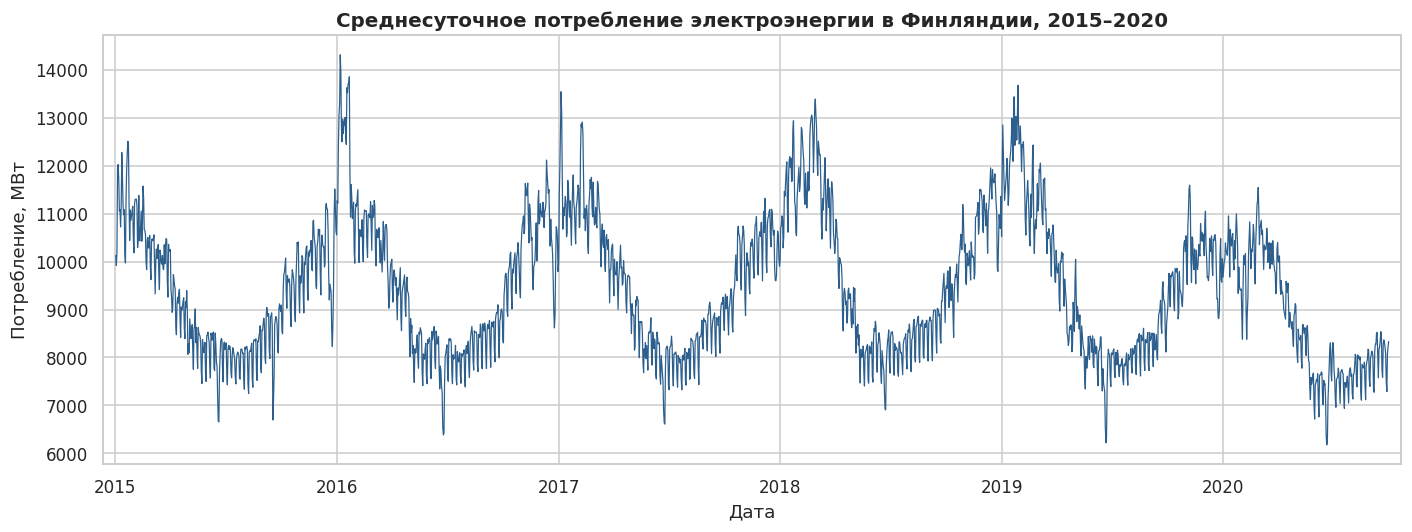

In [18]:
fig, ax = plt.subplots(figsize=(13, 5))

daily = df["load_mw"].resample("D").mean()
ax.plot(daily.index, daily.values, lw=0.8, color="#2c5f8d")

ax.set_title("Среднесуточное потребление электроэнергии в Финляндии, 2015–2020")
ax.set_xlabel("Дата")
ax.set_ylabel("Потребление, МВт")
ax.margins(x=0.01)

plt.tight_layout()
plt.savefig(IMG_DIR / "01_demand_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()

**Интерпретация.** Ряд колеблется с годовым циклом: острые зимние пики и пологие
летние впадины — характерная подпись системы, где спрос определяется отоплением.
Обратите внимание на относительную плоскость лета: в отличие от Испании или Италии,
в Финляндии нет крупной нагрузки на охлаждение, которая создавала бы второй пик.

### 7.2 Потребление и температура — ключевая зависимость

*Исследовательский вопрос 1.*

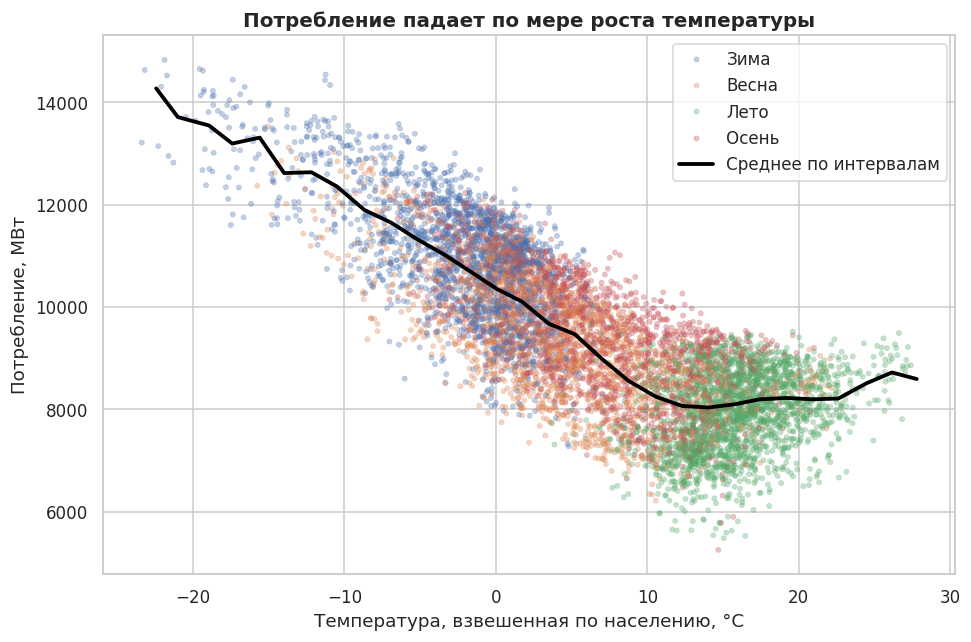

Корреляция температуры и потребления: -0.782


In [19]:
fig, ax = plt.subplots(figsize=(9, 6))

season_map = {12: "Зима", 1: "Зима", 2: "Зима",
              3: "Весна", 4: "Весна", 5: "Весна",
              6: "Лето", 7: "Лето", 8: "Лето",
              9: "Осень", 10: "Осень", 11: "Осень"}
df["season"] = df["month"].map(season_map)

sample = df.sample(min(8000, len(df)), random_state=RANDOM_STATE)

sns.scatterplot(
    data=sample, x="temperature", y="load_mw", hue="season",
    hue_order=["Зима", "Весна", "Лето", "Осень"],
    alpha=0.35, s=12, edgecolor=None, ax=ax,
)

# Среднее по интервалам поверх облака точек делает форму зависимости однозначной.
bins = pd.cut(df["temperature"], bins=30)
binned = df.groupby(bins, observed=True).agg(
    temp=("temperature", "mean"), load=("load_mw", "mean")
)
ax.plot(binned["temp"], binned["load"], color="black", lw=2.5,
        label="Среднее по интервалам")

ax.set_title("Потребление падает по мере роста температуры")
ax.set_xlabel("Температура, взвешенная по населению, °C")
ax.set_ylabel("Потребление, МВт")
ax.legend(title=None)

plt.tight_layout()
plt.savefig(IMG_DIR / "02_demand_vs_temperature.png", dpi=150, bbox_inches="tight")
plt.show()

print("Корреляция температуры и потребления: "
      f"{df['temperature'].corr(df['load_mw']):.3f}")

**Интерпретация.** Напишите здесь своё прочтение графика после запуска ячейки.
Что нужно раскрыть: знак и силу зависимости; прямая ли линия среднего по интервалам
или она изгибается вблизи порога включения отопления; выполаживается ли кривая в
тёплой части (отопление выключено, и ничто его не замещает); насколько плотно
разделяются сезоны — это показывает, объясняет ли спрос одна температура или сезон
несёт дополнительную информацию.

### 7.3 Суточный профиль потребления по сезонам

*Исследовательский вопрос 2.*

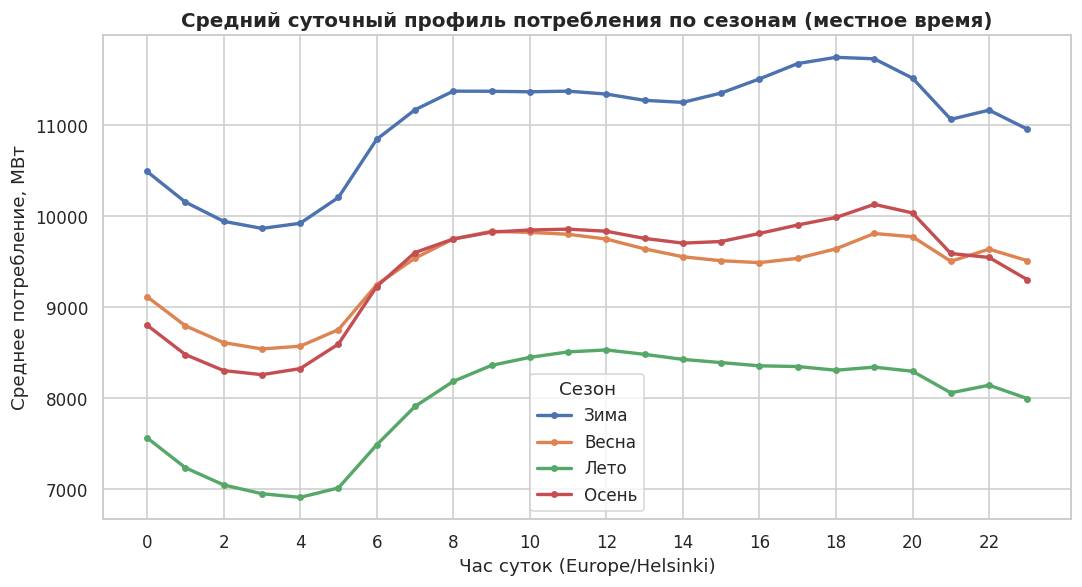

In [20]:
fig, ax = plt.subplots(figsize=(10, 5.5))

profile = df.groupby(["season", "hour"], observed=True)["load_mw"].mean().unstack(0)
profile = profile[["Зима", "Весна", "Лето", "Осень"]]

for col in profile.columns:
    ax.plot(profile.index, profile[col], lw=2.2, marker="o", ms=3.5, label=col)

ax.set_title("Средний суточный профиль потребления по сезонам (местное время)")
ax.set_xlabel("Час суток (Europe/Helsinki)")
ax.set_ylabel("Среднее потребление, МВт")
ax.set_xticks(range(0, 24, 2))
ax.legend(title="Сезон")

plt.tight_layout()
plt.savefig(IMG_DIR / "03_daily_profile.png", dpi=150, bbox_inches="tight")
plt.show()

**Интерпретация.** Опишите форму кривых: когда потребление растёт утром, есть ли
выраженный вечерний пик, насколько далеко друг от друга лежат зимняя и летняя
кривые. Вертикальный зазор между зимней и летней кривыми — это и есть отопительная
нагрузка, выраженная в мегаваттах.

### 7.4 Потребление по часам и месяцам

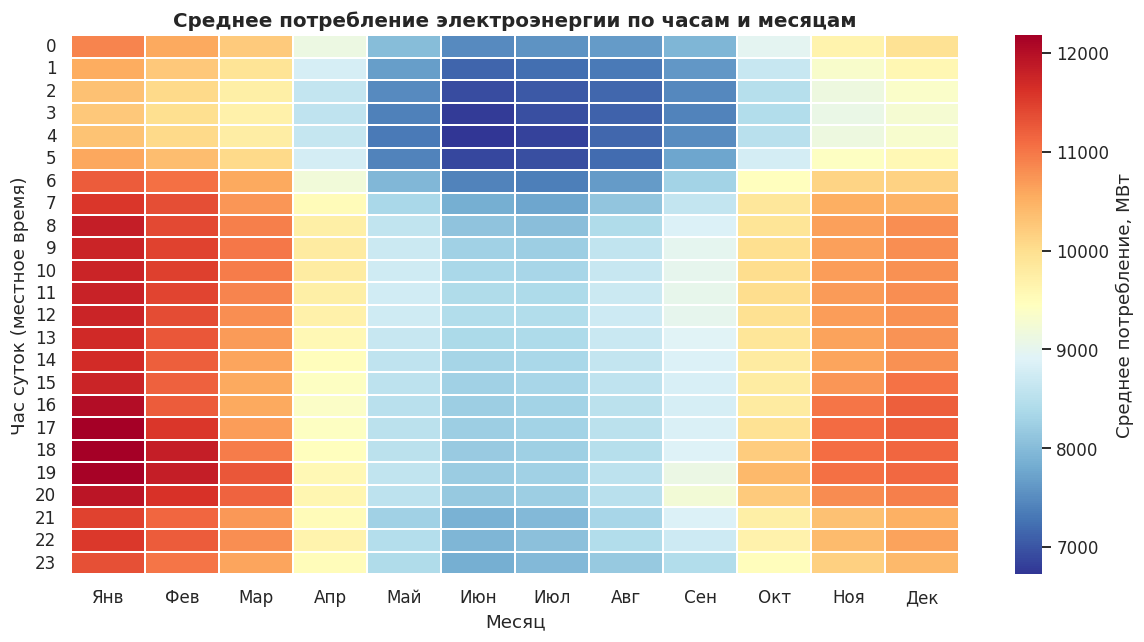

In [21]:
fig, ax = plt.subplots(figsize=(11, 6))

pivot = df.pivot_table(index="hour", columns="month", values="load_mw", aggfunc="mean")

sns.heatmap(
    pivot, cmap="RdYlBu_r", ax=ax,
    cbar_kws={"label": "Среднее потребление, МВт"},
    linewidths=0.3, linecolor="white",
)

ax.set_title("Среднее потребление электроэнергии по часам и месяцам")
ax.set_xlabel("Месяц")
ax.set_ylabel("Час суток (местное время)")
ax.set_xticklabels(
    ["Янв", "Фев", "Мар", "Апр", "Май", "Июн",
     "Июл", "Авг", "Сен", "Окт", "Ноя", "Дек"],
    rotation=0,
)

plt.tight_layout()
plt.savefig(IMG_DIR / "04_hour_month_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

**Интерпретация.** Тепловая карта объединяет оба цикла на одном рисунке. Определите,
где расположены самые «горячие» ячейки — в каких месяцах и в какие часы внутри них.
Именно этот блок часов система обязана обслуживать по установленной мощности.

### 7.5 Будни, выходные и праздники

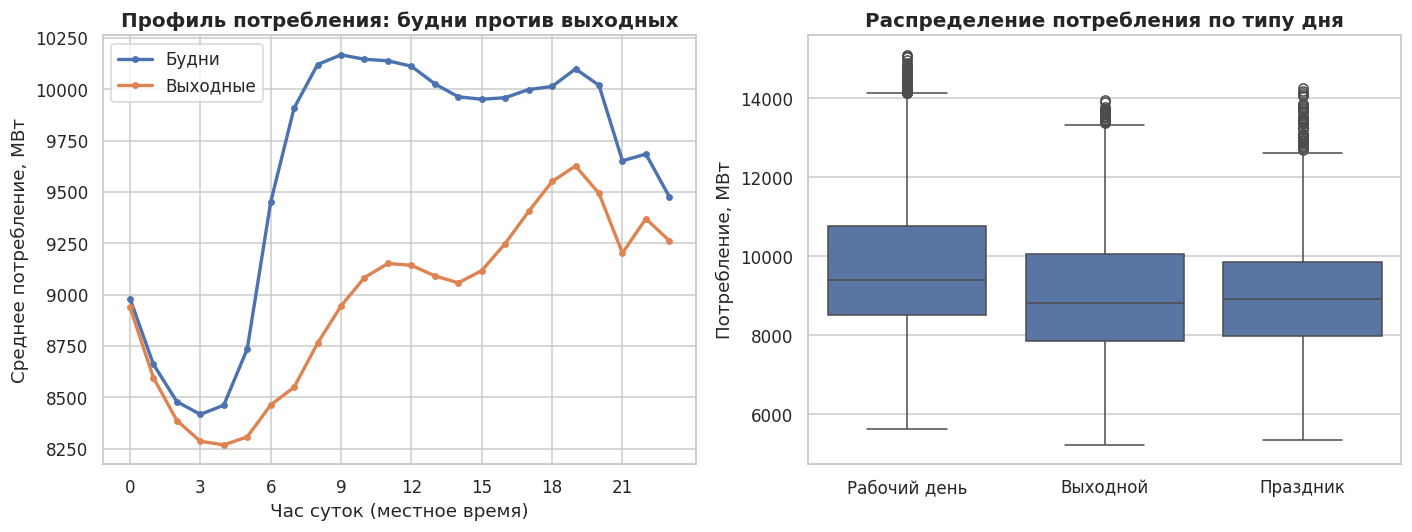

                mean     std  count
day_type                           
Выходной      8997.7  1445.8  13632
Праздник      8936.9  1530.7   2011
Рабочий день  9624.1  1540.4  34721


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Слева: профиль буднего дня против выходного
for label, subset in [("Будни", df[df["is_weekend"] == 0]),
                      ("Выходные", df[df["is_weekend"] == 1])]:
    prof = subset.groupby("hour")["load_mw"].mean()
    axes[0].plot(prof.index, prof.values, lw=2.2, marker="o", ms=3.5, label=label)

axes[0].set_title("Профиль потребления: будни против выходных")
axes[0].set_xlabel("Час суток (местное время)")
axes[0].set_ylabel("Среднее потребление, МВт")
axes[0].set_xticks(range(0, 24, 3))
axes[0].legend()

# Справа: сравнение распределений по типам дня
day_type = np.where(df["is_holiday"] == 1, "Праздник",
                    np.where(df["is_weekend"] == 1, "Выходной", "Рабочий день"))
plot_df = pd.DataFrame({"load_mw": df["load_mw"].values, "day_type": day_type})

sns.boxplot(
    data=plot_df, x="day_type", y="load_mw",
    order=["Рабочий день", "Выходной", "Праздник"], ax=axes[1],
)
axes[1].set_title("Распределение потребления по типу дня")
axes[1].set_xlabel("")
axes[1].set_ylabel("Потребление, МВт")

plt.tight_layout()
plt.savefig(IMG_DIR / "05_daytype.png", dpi=150, bbox_inches="tight")
plt.show()

print(plot_df.groupby("day_type")["load_mw"].agg(["mean", "std", "count"]).round(1))

**Интерпретация.** Оцените разрыв между буднями и выходными в мегаваттах и в
процентах. Механизм — промышленная и коммерческая активность. Отметьте, похожи ли
праздники на выходные или лежат ещё ниже.

### 7.6 Корреляции

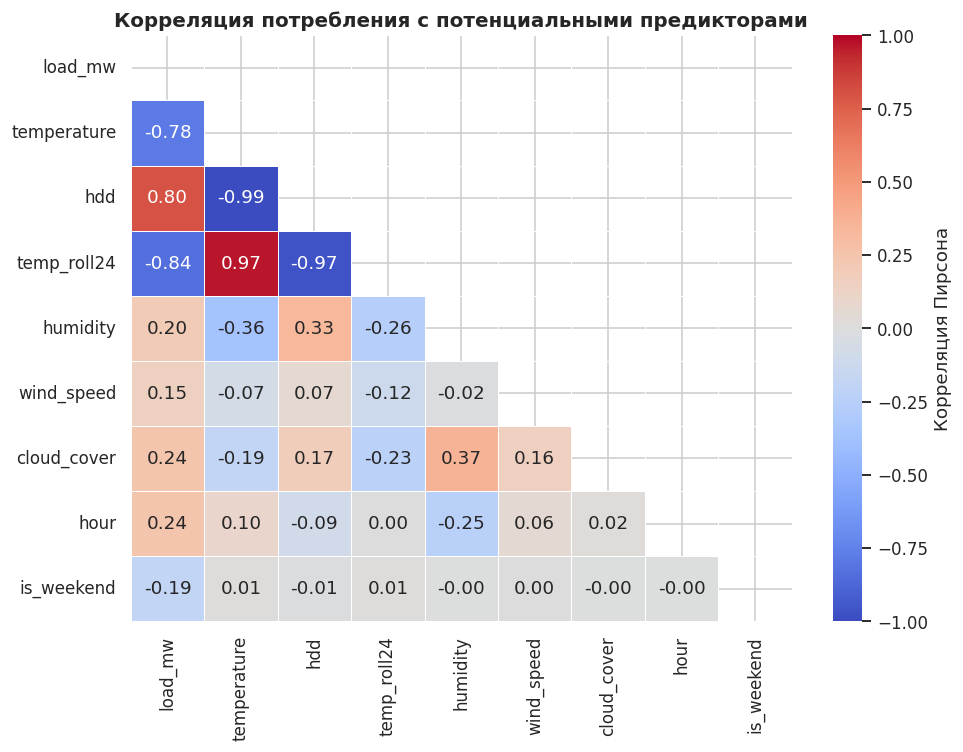

In [23]:
fig, ax = plt.subplots(figsize=(9, 7))

corr_cols = ["load_mw", "temperature", "hdd", "temp_roll24",
             "humidity", "wind_speed", "cloud_cover", "hour", "is_weekend"]
corr = df[corr_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5,
    cbar_kws={"label": "Корреляция Пирсона"},
)

ax.set_title("Корреляция потребления с потенциальными предикторами")

plt.tight_layout()
plt.savefig(IMG_DIR / "06_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

**Интерпретация.** Сравните корреляцию сырой температуры с корреляцией градусо-часов
отопления и скользящего среднего за 24 часа. Если производный признак коррелирует
сильнее сырой температуры, это свидетельство того, что инженерный признак лучше
улавливает физику процесса. Об этом стоит сказать прямо: так обосновывается
генерация признаков в разделе 6.

## 8. Модели машинного обучения

**Тип задачи:** регрессия. Целевая переменная `load_mw` непрерывна, поэтому метрики —
RMSE, MAE, MAPE и R².

**Стратегия разбиения — ключевое методологическое решение.** Случайное разбиение
поместило бы час *t+1* в обучающую выборку, а час *t* — в тестовую, то есть модель
«подсматривала» бы в будущее. Поскольку задача прогнозная, разбиение должно быть
**хронологическим**: обучение на ранних годах, тест на поздних.

In [24]:
FEATURES = [
    # Погода
    "temperature", "hdd", "cdd", "temp_lag24", "temp_roll24",
    "humidity", "wind_speed", "cloud_cover",
    # Календарь
    "hour_sin", "hour_cos", "doy_sin", "doy_cos",
    "dayofweek", "is_weekend", "is_holiday",
]
TARGET = "load_mw"

SPLIT_DATE = "2019-01-01"

train = df[df.index < SPLIT_DATE]
test = df[df.index >= SPLIT_DATE]

X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

print(f"Обучение: {len(X_train):,} часов ({train.index.min().date()} — {train.index.max().date()})")
print(f"Тест:     {len(X_test):,} часов ({test.index.min().date()} — {test.index.max().date()})")
print(f"Признаков: {len(FEATURES)}")

Обучение: 35,029 часов (2015-01-02 — 2018-12-31)
Тест:     15,335 часов (2019-01-01 — 2020-09-30)
Признаков: 15


In [25]:
def evaluate(name, y_true, y_pred):
    """Считает четыре метрики регрессии и возвращает их словарём."""
    return {
        "Модель": name,
        "RMSE, МВт": mean_squared_error(y_true, y_pred) ** 0.5,
        "MAE, МВт": mean_absolute_error(y_true, y_pred),
        "MAPE, %": mean_absolute_percentage_error(y_true, y_pred) * 100,
        "R2": r2_score(y_true, y_pred),
    }


results = []

### 8.1 Базовая модель: сезонная наивная

Прежде чем строить модели, нужно понять, чего достигает тривиальное решение. Модель,
которая не обходит правило «потребление равно значению неделю назад», не заслуживает
презентации.

In [26]:
# Предсказываем каждый тестовый час значением, отстоящим на 168 часов (неделю) назад.
naive = df[TARGET].shift(168).loc[test.index]
valid = naive.notna()

results.append(evaluate("Сезонная наивная (t−168 ч)", y_test[valid], naive[valid]))
pd.DataFrame(results).round(3)

,Модель,"RMSE, МВт","MAE, МВт","MAPE, %",R2
0,Сезонная наивная (t−168 ч),630.905,465.827,5.06,0.836


### 8.2 Линейная регрессия

Интерпретируемая базовая модель. Её коэффициенты читаются напрямую в физических
единицах — сколько мегаватт добавляет каждый градус похолодания.

In [27]:
lin = LinearRegression()
lin.fit(X_train, y_train)

y_pred_lin = lin.predict(X_test)
results.append(evaluate("Линейная регрессия", y_test, y_pred_lin))

coefs = (
    pd.DataFrame({"признак": FEATURES, "коэффициент": lin.coef_})
    .sort_values("коэффициент", key=abs, ascending=False)
)
print("Коэффициенты (по убыванию абсолютного влияния):")
print(coefs.round(2).to_string(index=False))

pd.DataFrame(results).round(3)

Коэффициенты (по убыванию абсолютного влияния):
    признак  коэффициент
 is_holiday      -775.81
 is_weekend      -666.03
   hour_cos      -588.96
   hour_sin      -579.79
    doy_cos       401.97
        hdd       289.43
temperature       194.17
        cdd      -136.78
    doy_sin      -127.56
 temp_lag24       -40.92
  dayofweek         5.91
temp_roll24        -5.44
 wind_speed         2.98
   humidity         2.27
cloud_cover         0.75


,Модель,"RMSE, МВт","MAE, МВт","MAPE, %",R2
0,Сезонная наивная (t−168 ч),630.905,465.827,5.060,0.836
1,Линейная регрессия,618.002,489.459,5.524,0.842


**Интерпретация.** Коэффициент при `hdd` стоит проговорить вслух на защите: это
дополнительные мегаватты национального потребления на каждый градусо-час отопления.
Именно это число — самый понятный для энергополитики результат всего ноутбука.

### 8.3 Случайный лес

Спрос реагирует на температуру нелинейно и взаимодействует со временем суток.
Ансамбль деревьев улавливает и то, и другое без явного указания.

In [28]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
results.append(evaluate("Случайный лес (базовый)", y_test, y_pred_rf))
pd.DataFrame(results).round(3)

,Модель,"RMSE, МВт","MAE, МВт","MAPE, %",R2
0,Сезонная наивная (t−168 ч),630.905,465.827,5.060,0.836
1,Линейная регрессия,618.002,489.459,5.524,0.842
2,Случайный лес (базовый),476.400,361.398,4.075,0.906


### 8.4 Подбор гиперпараметров

Для кросс-валидации используется `TimeSeriesSplit`, а не обычный k-fold: он всегда
проверяет модель на данных, более поздних, чем те, на которых она обучалась, сохраняя
хронологическую логику основного разбиения.

> Это самая долгая ячейка ноутбука. Если времени мало, сократите сетку параметров —
> этап настройки важнее как продемонстрированный метод, чем как источник крупного
> прироста точности.

In [29]:
param_grid = {
    "n_estimators": [150],
    "max_depth": [12, 20],
    "min_samples_leaf": [2, 5],
}

search = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=param_grid,
    cv=TimeSeriesSplit(n_splits=2),
    scoring="neg_root_mean_squared_error",
    verbose=1,
    n_jobs=1,          # параллелизм только внутри леса, без вложенности
)
search.fit(X_train, y_train)

print(f"\nЛучшие параметры: {search.best_params_}")
print(f"Лучший RMSE на кросс-валидации: {-search.best_score_:.1f} МВт")

best_rf = search.best_estimator_
y_pred_best = best_rf.predict(X_test)
results.append(evaluate("Случайный лес (настроенный)", y_test, y_pred_best))

results_df = pd.DataFrame(results).round(3)
results_df

Fitting 2 folds for each of 4 candidates, totalling 8 fits

Лучшие параметры: {'max_depth': 20, 'min_samples_leaf': 2, 'n_estimators': 150}
Лучший RMSE на кросс-валидации: 354.0 МВт


,Модель,"RMSE, МВт","MAE, МВт","MAPE, %",R2
0,Сезонная наивная (t−168 ч),630.905,465.827,5.060,0.836
1,Линейная регрессия,618.002,489.459,5.524,0.842
2,Случайный лес (базовый),476.400,361.398,4.075,0.906
3,Случайный лес (настроенный),476.877,361.893,4.080,0.906


### 8.5 Важность признаков

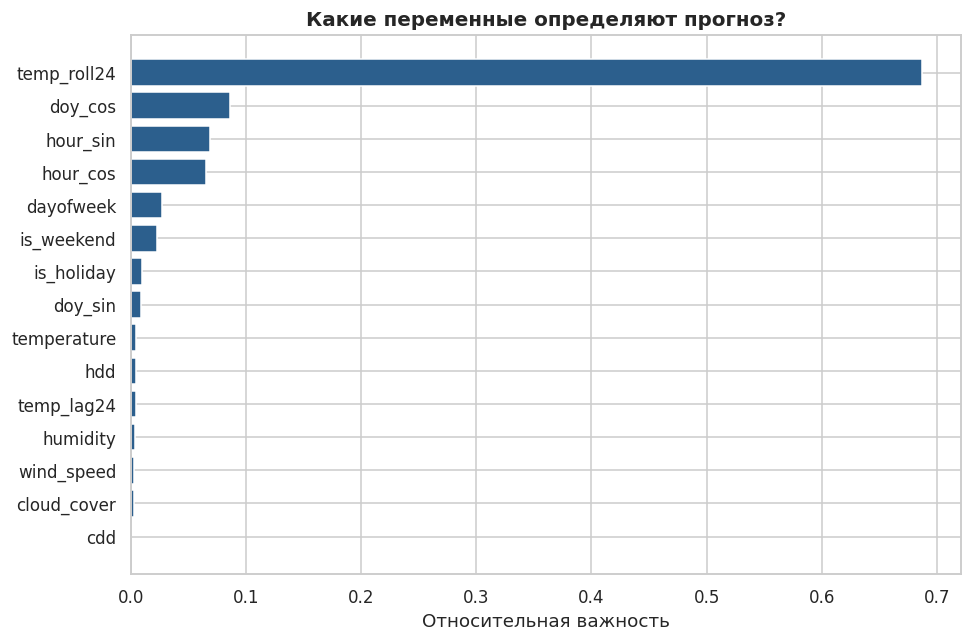

    признак  важность
temp_roll24    0.6869
    doy_cos    0.0866
   hour_sin    0.0689
   hour_cos    0.0655
  dayofweek    0.0271
 is_weekend    0.0232
 is_holiday    0.0094
    doy_sin    0.0087


In [30]:
fig, ax = plt.subplots(figsize=(9, 6))

importance = (
    pd.DataFrame({"признак": FEATURES, "важность": best_rf.feature_importances_})
    .sort_values("важность", ascending=True)
)

ax.barh(importance["признак"], importance["важность"], color="#2c5f8d")
ax.set_title("Какие переменные определяют прогноз?")
ax.set_xlabel("Относительная важность")

plt.tight_layout()
plt.savefig(IMG_DIR / "07_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print(importance.sort_values("важность", ascending=False).head(8).round(4).to_string(index=False))

**Предостережение для защиты.** Важности признаков у деревьев считаются по
разбиениям и размываются между коррелированными признаками. `temperature`, `hdd` и
`temp_roll24` кодируют один и тот же базовый сигнал, поэтому их индивидуальные
оценки занижают совокупную роль температуры. Скажите об этом сами, прежде чем
спросят.

### 8.6 Прогноз против факта

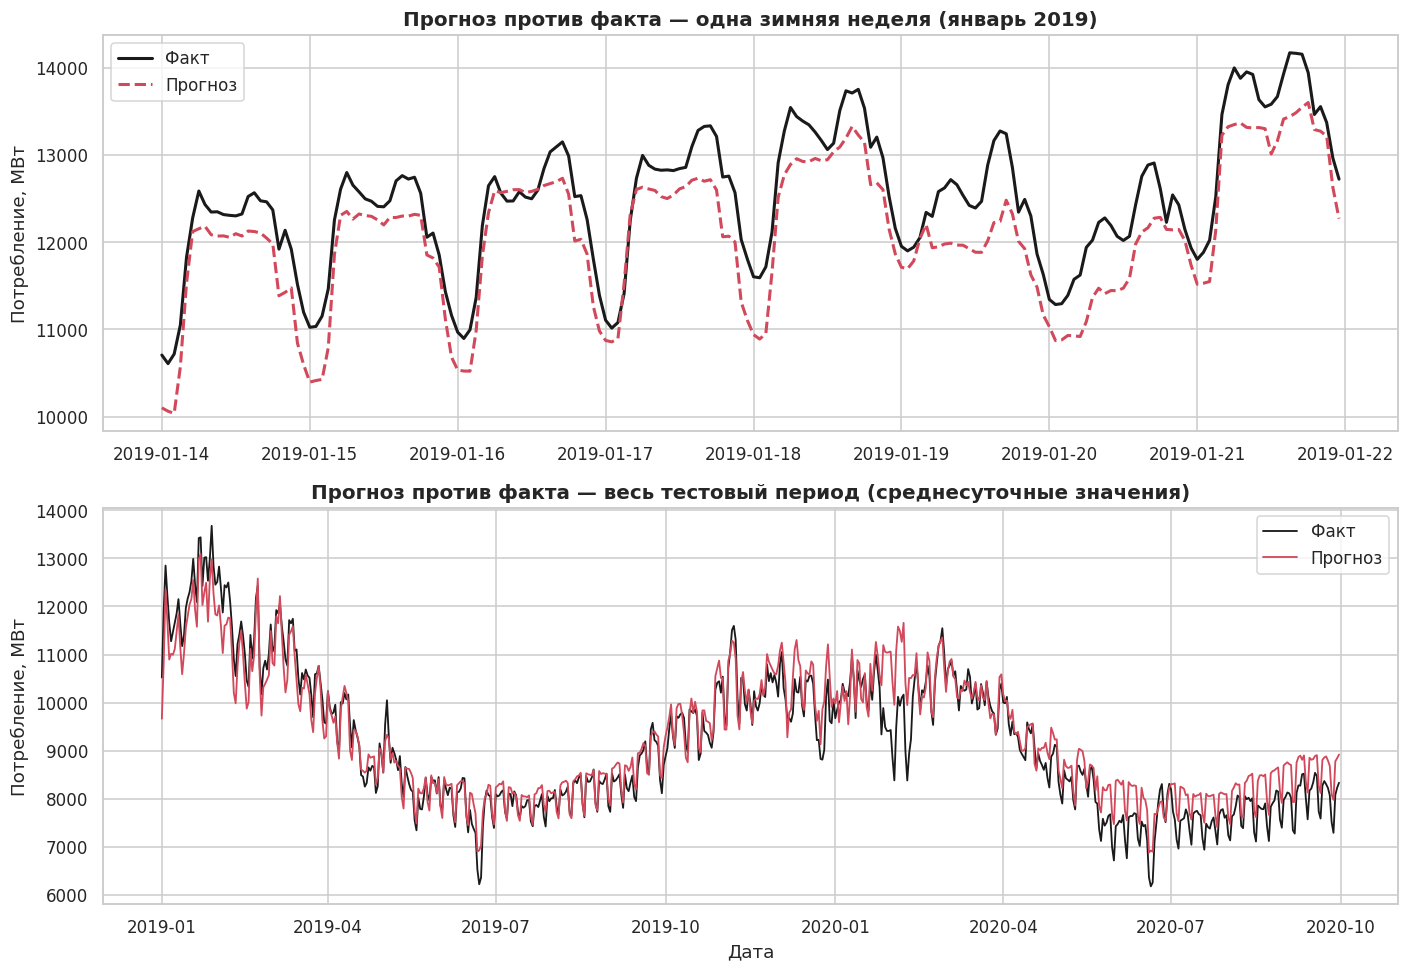

In [31]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9))

# Сверху: показательная зимняя неделя, когда точность важнее всего
week = test.loc["2019-01-14":"2019-01-21"]
week_pred = best_rf.predict(week[FEATURES])

axes[0].plot(week.index, week[TARGET], lw=2, label="Факт", color="#1a1a1a")
axes[0].plot(week.index, week_pred, lw=2, ls="--", label="Прогноз", color="#d1495b")
axes[0].set_title("Прогноз против факта — одна зимняя неделя (январь 2019)")
axes[0].set_ylabel("Потребление, МВт")
axes[0].legend()

# Снизу: весь тестовый период в суточном разрешении
comparison = pd.DataFrame(
    {"факт": y_test, "прогноз": y_pred_best}, index=test.index
).resample("D").mean()

axes[1].plot(comparison.index, comparison["факт"], lw=1.2, label="Факт", color="#1a1a1a")
axes[1].plot(comparison.index, comparison["прогноз"], lw=1.2, label="Прогноз", color="#d1495b")
axes[1].set_title("Прогноз против факта — весь тестовый период (среднесуточные значения)")
axes[1].set_ylabel("Потребление, МВт")
axes[1].set_xlabel("Дата")
axes[1].legend()

plt.tight_layout()
plt.savefig(IMG_DIR / "08_predicted_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

### 8.7 Анализ остатков — где модель ошибается

*Исследовательский вопрос 4.* Модель понята только тогда, когда поняты её ошибки.

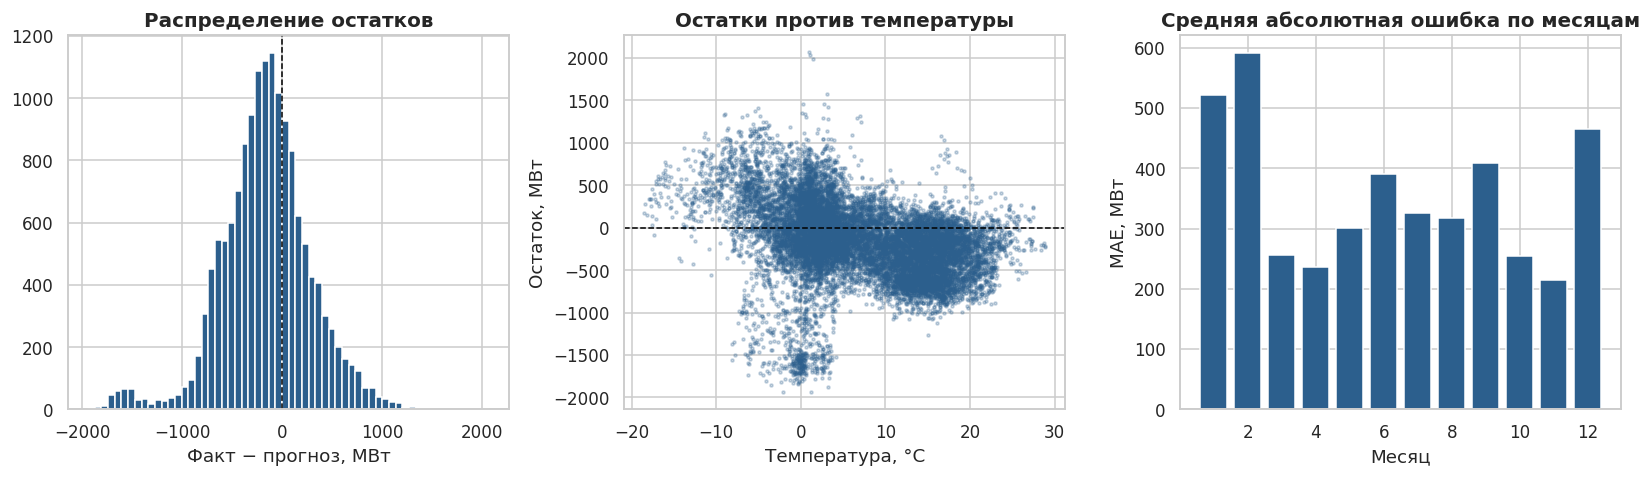

Средний остаток: -160.3 МВт (близость к нулю означает отсутствие систематического смещения)


In [32]:
residuals = pd.DataFrame({
    "факт": y_test,
    "прогноз": y_pred_best,
    "остаток": y_test - y_pred_best,
}, index=test.index)
residuals["temperature"] = test["temperature"]
residuals["month"] = test["month"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].hist(residuals["остаток"], bins=60, color="#2c5f8d", edgecolor="white")
axes[0].axvline(0, color="black", ls="--", lw=1)
axes[0].set_title("Распределение остатков")
axes[0].set_xlabel("Факт − прогноз, МВт")

axes[1].scatter(residuals["temperature"], residuals["остаток"],
                s=4, alpha=0.25, color="#2c5f8d")
axes[1].axhline(0, color="black", ls="--", lw=1)
axes[1].set_title("Остатки против температуры")
axes[1].set_xlabel("Температура, °C")
axes[1].set_ylabel("Остаток, МВт")

monthly_mae = residuals.groupby("month")["остаток"].apply(lambda s: s.abs().mean())
axes[2].bar(monthly_mae.index, monthly_mae.values, color="#2c5f8d")
axes[2].set_title("Средняя абсолютная ошибка по месяцам")
axes[2].set_xlabel("Месяц")
axes[2].set_ylabel("MAE, МВт")

plt.tight_layout()
plt.savefig(IMG_DIR / "09_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Средний остаток: {residuals['остаток'].mean():.1f} МВт "
      f"(близость к нулю означает отсутствие систематического смещения)")

In [33]:
# Тестовый период включает весну 2020 года. Сравниваем ошибку до и после введения
# ограничений COVID-19, чтобы проверить, сломалась ли модель на структурном сдвиге,
# который она не могла предвидеть по погоде и календарю.
pre_covid = residuals.loc[:"2020-03-15"]
post_covid = residuals.loc["2020-03-16":]

for label, subset in [("До 2020-03-16", pre_covid), ("После 2020-03-16", post_covid)]:
    if len(subset) == 0:
        continue
    mae = subset["остаток"].abs().mean()
    bias = subset["остаток"].mean()
    print(f"{label}: MAE = {mae:,.0f} МВт | среднее смещение = {bias:,.0f} МВт | n = {len(subset):,}")

До 2020-03-16: MAE = 329 МВт | среднее смещение = -55 МВт | n = 10,560
После 2020-03-16: MAE = 434 МВт | среднее смещение = -392 МВт | n = 4,775


**Интерпретация.** Отрицательное среднее смещение после марта 2020 года означает,
что фактическое потребление опустилось ниже предсказанного по погоде и календарю:
промышленная и коммерческая активность сократилась. Ни один погодный признак не мог
этого предвидеть. Это наглядная и честная иллюстрация предела любой модели, во
входных данных которой отсутствует изменившийся механизм.

### 8.8 Сравнение моделей

                     Модель  RMSE, МВт  MAE, МВт  MAPE, %    R2
 Сезонная наивная (t−168 ч)    630.905   465.827    5.060 0.836
         Линейная регрессия    618.002   489.459    5.524 0.842
    Случайный лес (базовый)    476.400   361.398    4.075 0.906
Случайный лес (настроенный)    476.877   361.893    4.080 0.906


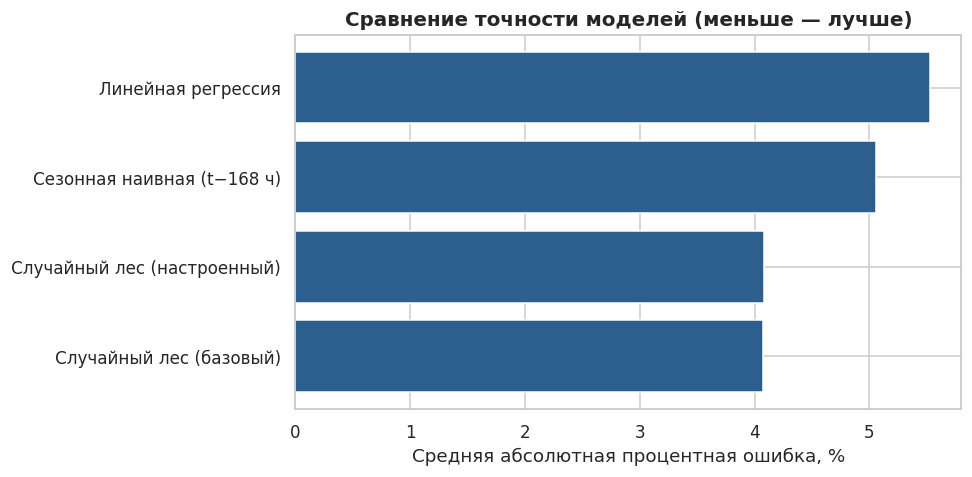

In [34]:
results_df = pd.DataFrame(results).round(3)
print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.5))
plot_data = results_df.sort_values("MAPE, %", ascending=True)
ax.barh(plot_data["Модель"], plot_data["MAPE, %"], color="#2c5f8d")
ax.set_title("Сравнение точности моделей (меньше — лучше)")
ax.set_xlabel("Средняя абсолютная процентная ошибка, %")

plt.tight_layout()
plt.savefig(IMG_DIR / "10_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

results_df.to_csv("model_results.csv", index=False)

## 9. Заключение

> Заполните значения в квадратных скобках фактическими результатами перед сдачей.
> Не оставляйте заглушки в финальной версии — незаполненный раздел результатов
> самая часто штрафуемая ошибка.

### Ключевые выводы

1. **Температура — главный драйвер потребления электроэнергии в Финляндии.**
   Корреляция температуры и потребления составляет [X]. Каждый градусо-час отопления
   добавляет примерно [X] МВт национального спроса.
   *(Отвечает на исследовательский вопрос 1.)*
2. **Потребление имеет устойчивый суточный и недельный ритм.** Зимнее потребление
   превышает летнее примерно на [X] МВт; рабочие дни превышают выходные примерно на
   [X] %. *(Отвечает на исследовательский вопрос 2.)*
3. **Погодные и календарные признаки предсказывают почасовое потребление с ошибкой
   MAPE [X] %** — без использования прошлых значений потребления. Настроенный
   случайный лес превзошёл и линейную модель, и сезонную наивную базовую.
   *(Отвечает на исследовательский вопрос 3.)*
4. **Ошибки распределены неравномерно.** Они концентрируются в [опишите], и после
   марта 2020 года у модели появилось систематическое смещение.
   *(Отвечает на исследовательский вопрос 4.)*

### Достигнуты ли поставленные цели?

Разберите по очереди и честно каждую из четырёх целей раздела 2.

### Ограничения

- **Ряд OPSD заканчивается в 2020 году**, поэтому модель не проверена на последних
  годах, включая европейский энергетический кризис 2022 года.
- **Погода представлена тремя городами.** Взвешивание по населению — приближение к
  реальному пространственному распределению нагрузки.
- **Авторегрессионные признаки не используются.** Их добавление заметно повысило бы
  точность, но ответило бы на другой вопрос: здесь выясняется, какую долю спроса
  объясняет только погода.
- **Структурный сдвиг COVID-19** в тестовом периоде занижает измеренное качество.
  Он описан, а не удалён.
- **Ансамбль деревьев не экстраполирует.** Температуры холоднее любых встречавшихся
  в обучающей выборке будут предсказаны как самые холодные из наблюдавшихся — это
  реальное ограничение для задач планирования мощности.

### Дальнейшая работа

- Расширить ряд напрямую через API платформы прозрачности ENTSO-E, которая
  обновляется и после 2020 года.
- Сравнить с градиентным бустингом (XGBoost, LightGBM, CatBoost).
- Добавить явные признаки взаимодействия «погода × час суток».
- **Повторить для Казахстана.** ERA5 покрывает Астану с тем же разрешением, что и
  Хельсинки, поэтому погодная половина пайплайна работает без изменений. Препятствие
  в другом: открытых почасовых данных о нагрузке казахстанской энергосистемы не
  публикуется. Эта асимметрия — свободно доступный климатический реанализ при
  недоступных национальных системных данных — и есть самый переносимый результат
  проекта.